# **11762 Content-Based Image Retrieval**
## Master's Degree in Intelligent Systems
### University of the Balearic Islands
---

##### Write in the following the names of the members of the group:
- **Member 1:** Einar López Altamirano
- **Member 2:** Victor Armando Canales Lima

# **Instructions**

You can find a **pre-configured Conda environment on Aula Digital** with everything required to complete the assignments.

**Do not delete any of the provided cells or functions**. Write your code in the indicated sections. You may add new cells or functions as needed to complete your work.  

Along with this assignment, please submit a comprehensive **report** in PDF format explaining your implemented solutions. The report should include, for example:

- **Technical Explanation**: Clearly describe the algorithms and techniques used, including the relevant code snippets.
- **Results**: Present your results in a clear and concise manner. Use visualizations such as graphs or tables to enhance understanding.
- **Analysis**: Interpret your results and discuss their significance. Consider, for instance, the following questions:
  - Are the results as expected? Why or why not?
  - What factors might have influenced them?
- **Conclusions**: Summarize your findings and provide overall conclusions about your project.
- ---

In [1]:
# Execute this cell to make sure 
# that external modules are reloaded
%load_ext autoreload
%autoreload 2


In [2]:
# Fill the following variable with
# the path to the Holidays (or Holidays Mini) dataset
dataset_dir = 'holidays_mini'

In [3]:
# Setup code for this assignment
import cv2
import math
import numpy as np
import os
import skimage.feature as skfeat
import zipfile
from holidays_dataset_handler import HolidaysDatasetHandler

import assignment1 as a1

# Configuring Matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

# **Introduction**
In this assignment, you will first learn the tools that will be used throughout the labs. Then, you will implement and evaluate various image description methods to develop a simple Content-Based Image Retrieval (CBIR) system.

### Tools
Several tools and libraries will be used throughout the semester, including:

*   [Python 3](https://docs.python.org/3/tutorial/)
*   [NumPy](https://docs.scipy.org/doc/numpy/user/quickstart.html)
*   [OpenCV](https://docs.opencv.org/master/d6/d00/tutorial_py_root.html)
*   [PyTorch](https://docs.pytorch.org/tutorials/beginner/basics/intro.html)

It is important to familiarize yourself with these tools. If you are not already familiar with them, please follow the links above and explore the tutorials. Quickstart guides are also available on the course website on [Aula Digital](https://ad.uib.es/).

### The INRIA Holidays Dataset
During this course, we will primarily use the INRIA Holidays dataset. This dataset consists of a collection of personal holiday photos from the authors, along with additional images purposefully taken to evaluate robustness to image transformations such as rotations, viewpoint changes, illumination variations, blurring, and more. The dataset includes a wide variety of scene types (natural landscapes, man-made structures, water, fire effects, etc.), with all images available in high resolution.

The dataset is organized into **500 groups**, each representing a distinct scene or object. For evaluation, the first image in each group serves as a **query image**, and the other images in the group are considered **relevant images** for that query. For example:

- *100900.jpg* is the query image.
- *100901.jpg* and *100902.jpg* are relevant images from the same group.

The dataset comprises a total of **1491 images**, including:

- **500 queries** (one for each group).
- **991 relevant images**.

### The INRIA Holidays Dataset (MINI)
To facilitate development, a reduced version of the INRIA Holidays dataset, called the *mini* dataset, is provided. **You should mainly use this version for this assignment.** It contains **50 images**, including:

- **19 queries**.
- **31 relevant images**.

> **Note**: Both datasets can be downloaded from [Aula Digital](https://ad.uib.es/). After downloading, unzip the files into a writable directory on your machine. Ensure that the corresponding variable at the beginning of this notebook is updated with the correct path to the dataset.

The datasets follow this structure:
```
holidays/
  ├── holidays_images.dat
  ├── images/
  │     ├── 100000.jpg
  │     ├── 100001.jpg
  │     └── ...
  └── features/
        ├── 100000.siftgeo
        ├── 100001.siftgeo
        └── ...
  ...
```
where:

- **`holidays_images.dat`**: This file lists the filenames of all images in the dataset.
- **`images/`**: Contains the high-resolution image files.
- **`features/`**: Includes the `.siftgeo` files, which store a set of extracted features (keypoints and descriptors) using SIFT for each image. Ensure these files are present if feature-based operations are required.

The `holidays_images.dat` file can also serve as ground truth for performance evaluation of retrieval systems, as explained in a later section.

### Using the *HolidaysDatasetHandler* Class
The `HolidaysDatasetHandler` class is designed to help you manage and interact with the INRIA Holidays dataset efficiently. It provides functionality for loading images, extracting keypoints and descriptors, and calculating evaluation metrics like Average Precision (AP) and Mean Average Precision (mAP).

**Key Features**
- Load and retrieve query/database images.
- Access ground truth data for evaluation.
- Load precomputed keypoints and descriptors for feature-based tasks.
- Compute AP and mAP for query evaluation.

#### Example Usage
**Importing and Initializing**
```python
# Initialize the dataset handler
dataset = HolidaysDatasetHandler(dataset_dir, load_features=True)
```

**Loading and Displaying an Image**
```python
# Get an image from the dataset
image_name = "100900.jpg"
image = dataset.get_image(image_name)

# Display the image
plt.imshow(image)
plt.axis('off')  # Optional, to hide axes
plt.show()
```

**Accesing Query and Database Images**
```python
# List all query images
query_images = dataset.get_query_images()
print(f"Number of query images: {len(query_images)}")

# List all database images
database_images = dataset.get_database_images()
print(f"Number of database images: {len(database_images)}")
```

**Loading Keypoints and Descriptors**
```python
# Load keypoints and descriptors for a specific image
kps = dataset.get_kps("100900.jpg")
descs = dataset.get_descriptors("100900.jpg")

# Print the first keypoint and its descriptor
print(f"Keypoint: {kps[0].pt}, Descriptor shape: {descs.shape}")
```

**Computing Average Precision (AP)**
```python
# Compute AP for a single query with a ranked list of images
query_name = "100900.jpg"
ranked_list = ["100901.jpg", "100902.jpg"]
ap = dataset.compute_AP(query_name, ranked_list)
print(f"Average Precision (AP) for {query_name}: {ap}")
```

**Computing Mean Average Precision (mAP)**
```python
# Compute mAP for multiple queries
ranked_dict = {
    "100900.jpg": ["100901.jpg", "100902.jpg"],
    "101000.jpg": ["101001.jpg"]
}
map_score = dataset.compute_mAP(ranked_dict)
print(f"Mean Average Precision (mAP): {map_score}")
```

# **Global Descriptors**

Once our development environment is set up, we can begin working on the assignment. In this section, we will explore and evaluate various global descriptors to build a simple image retrieval system.

### General Framework

To streamline our workflow, we will begin by developing essential utility functions and classes. Start by implementing a [Python class]((https://docs.python.org/3/tutorial/classes.html)) named `CBIR` in `assignment1.py`, which will encapsulate the core functionalities of a CBIR system. The class should adhere to the provided method descriptions. Assume the existence of a function, `desc_func`, that computes a global descriptor for a given image. This design enables the use of the same class with different descriptor methods, as we will explore later in the assignment.

### Color Histograms
- Let's begin with histograms. In the `assignment1.py` file, implement the function `compute_1d_color_hist` to compute a descriptor based on a 1D color histogram. The final image descriptor will be the concatenation of the **normalized** color histograms from the three individual channels (B, G, and R).

- Next, implement the function called `compute_2d_color_hist` to compute a global descriptor for the image using 2D color histograms. The image descriptor will be the concatenation of the **normalized** histograms derived from the three possible combinations of color channels (B/G, B/R, and G/R).

> **Useful functions**: [cv2.calcHist](https://docs.opencv.org/4.2.0/d6/dc7/group__imgproc__hist.html), [np.histogram](https://docs.scipy.org/doc/numpy/reference/generated/numpy.histogram.html)

Check your implementations using the following cell:

In [4]:
# Initialize the dataset handler
dataset = HolidaysDatasetHandler(dataset_dir, load_features=False) # We don't need features now

# Get an image from the dataset
image_name = "100900.jpg"
image = dataset.get_image(image_name)

# Bins: 32
h = a1.compute_1d_color_hist(image, 32);
assert h.shape == (96, )

# Bins: 16
h = a1.compute_1d_color_hist(image, 16);
assert h.shape == (48, )

# Bins: 8
h = a1.compute_1d_color_hist(image, 8);
assert h.shape == (24, )

# Bins: 32
h = a1.compute_2d_color_hist(image, 32);
assert h.shape == (3072, )

# Bins: 16
h = a1.compute_2d_color_hist(image, 16);
assert h.shape == (768, )

Before starting the tasks, we preloaded database images and query names to avoid redundant loading

In [23]:
db_images = {name: dataset.get_image(name) for name in dataset.get_database_images()}
query_names = dataset.get_query_images()

**Task 1:**

Using the `HolidaysDatasetHandler` and `CBIR` classes, your task in the following cell is to compute the **mean Average Precision (mAP)** of this image retrieval system on this dataset. The image descriptors should be calculated using **1D histograms** with **8 bins**.

In [ ]:

# Fill this variable with the resulting mAP
mAP_hist_1d = 0.0


# YOUR CODE HERE
# Initialize CBIR and build database
cbir_1d = a1.CBIR(a1.compute_1d_color_hist, bins_per_hist=8)
cbir_1d.build_image_db(db_images)

# Search for each query
mAP_dict = {}
for q_name in query_names:
    q_img = dataset.get_image(q_name)
    q_desc = a1.compute_1d_color_hist(q_img, bins_per_hist=8)
    
    mAP_dict[q_name] = [name for name, _ in cbir_1d.search_image(q_desc)]

# 3. Compute metric
mAP_hist_1d = dataset.compute_mAP(mAP_dict)

# -----

print('Mean Average Precision (mAP): %.5f' % mAP_hist_1d)

Mean Average Precision (mAP): 0.74751


**Task 2:**

Study the effect of changing the number of bins per histogram.

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

In [27]:
bins_per_hist_arr = [2, 4, 8, 16, 32, 64, 128, 255]

for bins in bins_per_hist_arr:
    cbir = a1.CBIR(a1.compute_1d_color_hist, bins_per_hist=bins)
    cbir.build_image_db(db_images)
    
    mAP_dict = {}
    for q_name in query_names:
        q_img = dataset.get_image(q_name)
        q_desc = a1.compute_1d_color_hist(q_img, bins_per_hist=bins)
        mAP_dict[q_name] = [name for name, _ in cbir.search_image(q_desc)]
        
    curr_mAP = dataset.compute_mAP(mAP_dict)
    print(f"mAP: {curr_mAP:.5f} | bins in hist: {bins}")

mAP: 0.30122 | bins in hist: 2
mAP: 0.65141 | bins in hist: 4
mAP: 0.74751 | bins in hist: 8
mAP: 0.66898 | bins in hist: 16
mAP: 0.66644 | bins in hist: 32
mAP: 0.68872 | bins in hist: 64
mAP: 0.67251 | bins in hist: 128
mAP: 0.67906 | bins in hist: 255


**Task 3:**

Again, using the `HolidaysDatasetHandler` and `CBIR` classes, your task in the following cell is to compute the **mean Average Precision (mAP)** of this image retrieval system on this dataset. However, this time the image descriptors should be calculated using **2D histograms** with **8 bins**.

In [28]:
# Fill this variable with the resulting mAP
mAP_hist_2d = 0.0

# YOUR CODE HERE
cbir_2d = a1.CBIR(a1.compute_2d_color_hist, bins_per_hist=8)
cbir_2d.build_image_db(db_images)

mAP_dict = {}
for q_name in query_names:
    q_img = dataset.get_image(q_name)
    q_desc = a1.compute_2d_color_hist(q_img, bins_per_hist=8)
    mAP_dict[q_name] = [name for name, _ in cbir_2d.search_image(q_desc)]

mAP_hist_2d = dataset.compute_mAP(mAP_dict)
# -----

print('Mean Average Precision (mAP): %.5f' % mAP_hist_2d)

Mean Average Precision (mAP): 0.73546


**Task 4:**

As for the 1D case, study the effect of changing the number of bins per histogram.

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

In [29]:
bins_per_hist_arr = [2, 4, 8, 16, 32, 64, 128, 255]

for bins in bins_per_hist_arr:
    cbir = a1.CBIR(a1.compute_2d_color_hist, bins_per_hist=bins)
    cbir.build_image_db(db_images)
    
    mAP_dict = {}
    for q_name in query_names:
        q_img = dataset.get_image(q_name)
        q_desc = a1.compute_2d_color_hist(q_img, bins_per_hist=bins)
        mAP_dict[q_name] = [name for name, _ in cbir.search_image(q_desc)]
        
    curr_mAP = dataset.compute_mAP(mAP_dict)
    print(f"mAP: {curr_mAP:.5f} | bins in hist: {bins}")

mAP: 0.45852 | bins in hist: 2
mAP: 0.72100 | bins in hist: 4
mAP: 0.73546 | bins in hist: 8
mAP: 0.74269 | bins in hist: 16
mAP: 0.65381 | bins in hist: 32
mAP: 0.68673 | bins in hist: 64
mAP: 0.62454 | bins in hist: 128
mAP: 0.60345 | bins in hist: 255


**Task 5:**

What other options can be implemented to improve the quality of retrieval using histograms? Experiment with some of them.

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

### Local Binary Patterns (LBP)

Let's try LBP. Implement the function called `compute_lbp_descriptor` to calculate an image descriptor based on LBP. The descriptor should use the *rotation-invariant and uniform (RIU)* version of the algorithm. The final image descriptor will be the normalized histogram of the resulting LBP image.

> **Useful functions**: [skimage.feature.local_binary_pattern](https://scikit-image.org/docs/dev/api/skimage.feature.html?highlight=lbp#skimage.feature.local_binary_pattern)

Check your implementation using the following cell:

In [9]:
h = a1.compute_lbp_descriptor(image, 8, 1);
assert h.shape == (10, )

**Task 6:**

As previously, your task in the following cell is to compute the **mean Average Precision (mAP)** of this image retrieval system on this dataset using the `HolidaysDatasetHandler` and `CBIR` classes. However, this time, the descriptors should be calculated using the `compute_lbp_descriptor` function using **8 neighbors for each pixel at a distance of 1 pixel**.

In [30]:
# Fill this variable with the resulting mAP
mAP_lbp = 0.0

# YOUR CODE HERE
cbir_lbp = a1.CBIR(a1.compute_lbp_descriptor, p=8, r=1)
cbir_lbp.build_image_db(db_images)

mAP_dict = {}
for q_name in query_names:
    q_img = dataset.get_image(q_name)
    q_desc = a1.compute_lbp_descriptor(q_img, p=8, r=1)
    mAP_dict[q_name] = [name for name, _ in cbir_lbp.search_image(q_desc)]

mAP_lbp = dataset.compute_mAP(mAP_dict)
# -----

print('Mean Average Precision (mAP): %.5f' % mAP_lbp)

Mean Average Precision (mAP): 0.61529


**Task 7:**

Study the effect of changing the number of neighboring pixels $p$ and the radius $r$.

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

In [31]:
neigh_rad_arr = [(4,1), (8,1), (4,2), (8,2)]

for neigh, rad in neigh_rad_arr:
    cbir = a1.CBIR(a1.compute_lbp_descriptor, p=neigh, r=rad)
    cbir.build_image_db(db_images)
    
    mAP_dict = {}
    for q_name in query_names:
        q_img = dataset.get_image(q_name)
        q_desc = a1.compute_lbp_descriptor(q_img, p=neigh, r=rad)
        mAP_dict[q_name] = [name for name, _ in cbir.search_image(q_desc)]
        
    curr_mAP = dataset.compute_mAP(mAP_dict)
    print(f"mAP: {curr_mAP:.5f} | neighbors: {neigh}, rad: {rad}")

mAP: 0.56104 | neighbors: 4, rad: 1
mAP: 0.61529 | neighbors: 8, rad: 1
mAP: 0.64532 | neighbors: 4, rad: 2
mAP: 0.49486 | neighbors: 8, rad: 2


**Task 8:**

Implement a grid over the image, computing the LBP histogram for each cell. Then, concatenate these histograms to form a global descriptor for the image. Investigate the impact of this improvement on the retrieval performance.

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

In [32]:
# Fill this variable with the resulting mAP
mAP_global_lbp = 0.0

# YOUR CODE HERE
cbir_global = a1.CBIR(a1.compute_global_lbp_descriptor, p=8, r=1, grid_x=2, grid_y=2)
cbir_global.build_image_db(db_images)

mAP_dict = {}
for q_name in query_names:
    q_img = dataset.get_image(q_name)
    q_desc = a1.compute_global_lbp_descriptor(q_img, p=8, r=1, grid_x=2, grid_y=2)
    mAP_dict[q_name] = [name for name, _ in cbir_global.search_image(q_desc)]

mAP_global_lbp = dataset.compute_mAP(mAP_dict)
# -----

print('Mean Average Precision (mAP): %.5f' % mAP_global_lbp)


Mean Average Precision (mAP): 0.73307


In [33]:
neigh_rad_arr = [(4,1,2,2), (8,1,2,2), (4,2,2,2), (8,2,2,2)]

for neigh, rad, gx, gy in neigh_rad_arr:
    cbir = a1.CBIR(a1.compute_global_lbp_descriptor, p=neigh, r=rad, grid_x=gx, grid_y=gy)
    cbir.build_image_db(db_images)
    
    mAP_dict = {}
    for q_name in query_names:
        q_img = dataset.get_image(q_name)
        q_desc = a1.compute_global_lbp_descriptor(q_img, p=neigh, r=rad, grid_x=gx, grid_y=gy)
        mAP_dict[q_name] = [name for name, _ in cbir.search_image(q_desc)]
        
    curr_mAP = dataset.compute_mAP(mAP_dict)
    print(f"mAP: {curr_mAP:.5f} | neighbors: {neigh}, rad: {rad}, grid: ({gx},{gy})")

mAP: 0.72701 | neighbors: 4, rad: 1, grid: (2,2)
mAP: 0.73307 | neighbors: 8, rad: 1, grid: (2,2)
mAP: 0.72923 | neighbors: 4, rad: 2, grid: (2,2)
mAP: 0.57635 | neighbors: 8, rad: 2, grid: (2,2)


# **Local Descriptors**

In this section, we will focus on retrieving images by leveraging local descriptors discussed during the class. These descriptors will help us analyze and compare images based on their distinct visual features.

### Extracting Interest Points

Let's start by writing the function `extract_interest_points` in `assignment1.py` to extract a set of keypoints from an image along with their corresponding descriptors. The function will take a parameter called `feat_type` to specify the method used for keypoint detection and description. This parameter can have one of the following string values:

- **`SIFT`**: SIFT detector and descriptor.
- **`FAST_BRIEF`**: FAST detector with BRIEF descriptor.
- **`ORB`**: ORB detector and descriptor.


> **Useful functions**: [cv2.SIFT_create()](https://docs.opencv.org/4.5.4/d7/d60/classcv_1_1SIFT.html#ad337517bfdc068ae0ba0924ff1661131), [cv2.FastFeatureDetector_create](https://docs.opencv.org/4.5.4/df/d74/classcv_1_1FastFeatureDetector.html#ab986f2ff8f8778aab1707e2642bc7f8e), [cv2.xfeatures2d.BriefDescriptorExtractor_create](https://docs.opencv.org/4.5.4/d1/d93/classcv_1_1xfeatures2d_1_1BriefDescriptorExtractor.html#ae3bc52666010fb137ab6f0d32de51f60), [cv2.ORB_create](https://docs.opencv.org/4.5.4/db/d95/classcv_1_1ORB.html#aeff0cbe668659b7ca14bb85ff1c4073b)

By combining these tools, you can implement the function to handle different types of keypoint detection and description techniques effectively.

Check your implementation using the following cell:

1939 keypoints detected.
Descriptors shape: (1939, 128)


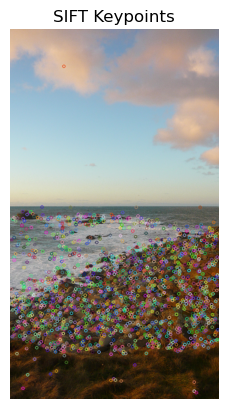

In [14]:
# Initialize the dataset handler
dataset = HolidaysDatasetHandler(dataset_dir, load_features=False) # We don't need features now

# Get an image from the dataset
image_name = "100800.jpg"
image = dataset.get_image(image_name)

# Check if the image was loaded correctly
if image is None:
    print(f"Error: Could not load the image {image_name}.")
else:
    # Extract interest points and descriptors
    img_resized = cv2.resize(image, None, fx=0.25, fy=0.25, interpolation = cv2.INTER_CUBIC)
    kps, des = a1.extract_interest_points(img_resized, 'SIFT', nfeats=2000, thresh=75)
    
    # Check if any keypoints were detected
    if len(kps) == 0:
        print("No keypoints were detected in the image.")
    else:
        print(f"{len(kps)} keypoints detected.")
        # Display the shape of the descriptors
        print(f"Descriptors shape: {des.shape}")
        
        # Draw the keypoints on the image
        sift_image = cv2.drawKeypoints(img_resized, kps, None)
        
        # Display the image without axes
        plt.imshow(sift_image)  # Convert BGR to RGB for Matplotlib
        plt.axis('off')  # Remove axes
        plt.title('SIFT Keypoints')
        plt.show()

### Matching Images

- Next, implement the function called `find_matches` to match two sets of descriptors. Since descriptor types vary, we will use:
    - **Brute-force matching** for binary descriptors (e.g., BRIEF, ORB).  
    - **FLANN-based matching** for floating-point descriptors (e.g., SIFT).
            
-  Implement the function called `filter_matches` to refine the matching results using the **Nearest Neighbor Distance Ratio (NNDR) criterion**. This method helps remove ambiguous matches by ensuring that the best match is significantly better than the second-best match. This helps to discard ambiguous matches and improves robustness by reducing false positives.

> **Useful links**: [cv2.BFMatcher_create](https://docs.opencv.org/4.5.4/d3/da1/classcv_1_1BFMatcher.html#ac6418c6f87e0e12a88979ea57980c020), [cv2.FlannBasedMatcher](https://docs.opencv.org/4.5.4/dc/de2/classcv_1_1FlannBasedMatcher.html#a7b17083dda906384465a32952c1bbe3b), [Feature Matching](https://docs.opencv.org/4.5.4/dc/dc3/tutorial_py_matcher.html)

### Filtering Matches

Implement the function called `filter_matches` to refine the matching results using the **Nearest Neighbor Distance Ratio (NNDR) criterion**. This method helps remove ambiguous matches by ensuring that the best match is significantly better than the second-best match.

Check your implementation of these functions using the following cell:

Raw matches found: 2000
Filtered matches: 260


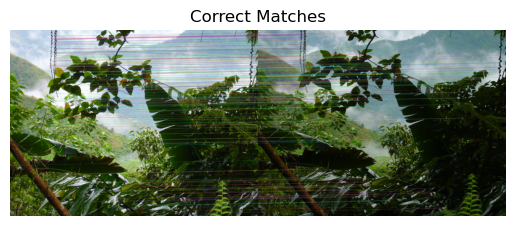

In [15]:
# Initialize the dataset handler
dataset = HolidaysDatasetHandler(dataset_dir, load_features=False)  # We don't need features now

# Get images from the dataset
image1_name = "100100.jpg"
image2_name = "100101.jpg"

image1 = dataset.get_image(image1_name)
image2 = dataset.get_image(image2_name)

# Check if images were loaded correctly
if image1 is None or image2 is None:
    print("Error: One or both images could not be loaded.")
else:
    # Extract keypoints and descriptors for both images
    kps_q, des_q = a1.extract_interest_points(image1, 'SIFT', nfeats=2000, thresh=25)
    kps_t, des_t = a1.extract_interest_points(image2, 'SIFT', nfeats=2000, thresh=25)

    # Check if descriptors were extracted properly
    if des_q is None or des_t is None or len(des_q) == 0 or len(des_t) == 0:
        print("Error: No descriptors found in one or both images.")
    else:
        # Find and filter matches
        raw_matches = a1.find_matches(des_q, des_t)
        print(f"Raw matches found: {len(raw_matches)}")

        matches = a1.filter_matches(raw_matches, ratio=0.6)
        print(f"Filtered matches: {len(matches)}")

        # Draw matches
        img_matches = cv2.drawMatches(
            image1, kps_q, image2, kps_t, matches, None, 
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )

        # Display the result
        plt.imshow(img_matches)
        plt.axis('off')  # Remove axes for a cleaner display
        plt.title('Correct Matches')
        plt.show()


## Evaluating Performance

Using the `HolidaysDatasetHandler` and the functions you have implemented, your task is to complete the `evaluate` function in `assignment1.py` to compute the **mean Average Precision (mAP)** for an image retrieval system based on **local image features**. This time, images will be compared using **local feature descriptors**. Given a query image, the closest match in the database will be the **image with the highest number of matches after filtering**. You should apply a **threshold** to determine the minimum number of matches required for an image to be considered a **correct match**.

**Task 9:**

In the following cell, your task is to compute the **mean Average Precision (mAP)** for the image retrieval system using the `evaluate()` function. The goal is to evaluate the retrieval system's performance for each method (SIFT, FAST/BRIEF, and ORB) and fine-tune their respective parameters to achieve the best possible mAP.

For each method:
1. **SIFT**: Adjust parameters such as the number of features (`nfeats`) and the threshold (`thresh`).
2. **FAST/BRIEF**: Experiment with the number of keypoints, thresholds, and descriptors.
3. **ORB**: Modify the number of features (`nfeats`) and other relevant settings.

Your objective is to achieve the highest mAP score by optimizing these parameters for each method.

In [16]:
# Fill these variables with the best resulting mAPs
best_mAP_SIFT = 0.0
best_mAP_FASTBRIEF = 0.0
best_mAP_ORB = 0.0

# YOUR CODE HERE

best_mAP_SIFT = a1.evaluate(dataset, 'SIFT', 1000, 25, 0.75)
best_mAP_FASTBRIEF = a1.evaluate(dataset, 'FAST_BRIEF', 1000, 25, 0.75)
best_mAP_ORB =  a1.evaluate(dataset, 'ORB', 1000, 25, 0.75)
# -----

# Print the best mAPs for each method
print('Best mAP (SIFT): %.5f' % best_mAP_SIFT)
print('Best mAP (FAST/BRIEF): %.5f' % best_mAP_FASTBRIEF)
print('Best mAP (ORB): %.5f' % best_mAP_ORB)

Best mAP (SIFT): 0.67990
Best mAP (FAST/BRIEF): 0.68706
Best mAP (ORB): 0.73009


**Task 10:**

Compare the three methods in terms of accuracy. Which one is the most accurate? Which one is the least accurate?

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

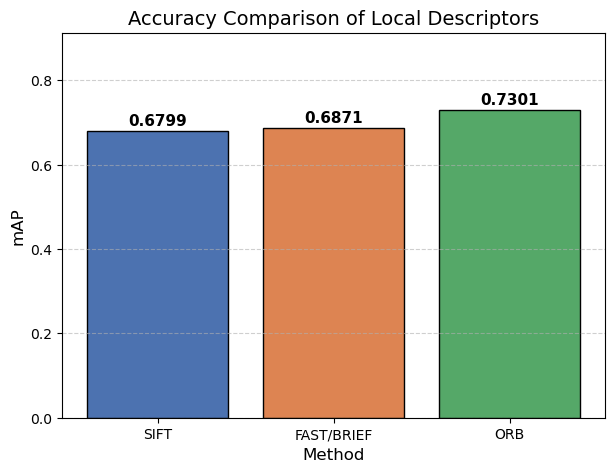

Ranking by accuracy (mAP):
  1. ORB: 0.73009
  2. FAST/BRIEF: 0.68706
  3. SIFT: 0.67990

-> Most accurate method:  ORB
-> Least accurate method: SIFT


In [20]:
import matplotlib.pyplot as plt

methods = ['SIFT', 'FAST/BRIEF', 'ORB']
mAP_scores = [best_mAP_SIFT, best_mAP_FASTBRIEF, best_mAP_ORB]
bar_colors = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(7, 5))
bars = plt.bar(methods, mAP_scores, color=bar_colors, edgecolor='black')

# Annotate each bar with its exact mAP value
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.005, 
             f'{yval:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, max(mAP_scores) * 1.25) # Add headroom for labels
plt.xlabel('Method', fontsize=12)
plt.ylabel('mAP', fontsize=12)
plt.title('Accuracy Comparison of Local Descriptors', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Print a ranked summary
ranked = sorted(zip(methods, mAP_scores), key=lambda x: x[1], reverse=True)
print("Ranking by accuracy (mAP):")
for rank, (method, score) in enumerate(ranked, 1):
    print(f"  {rank}. {method}: {score:.5f}")

print(f"\n-> Most accurate method:  {ranked[0][0]}")
print(f"-> Least accurate method: {ranked[-1][0]}")

**Task 11:**

Compare the three methods in terms of detection and description speed. Which one is the fastest? Which one is the slowest?

> **Hints**:
> - [Here](https://jakevdp.github.io/PythonDataScienceHandbook/01.07-timing-and-profiling.html) you can find a useful resource on timing in Jupyter Notebooks.
> - You can also consider using the `time` module.
> - To provide a measure independent of the number of features detected, you can compute, for example, features per millisecond (features/ms).

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

Method       | Avg Time (ms)   | Avg Feats  | Feats/ms  
-------------------------------------------------------
SIFT         | 1270.78         | 983.8      | 0.77      
FAST/BRIEF   | 81.98           | 26605.3    | 324.54    
ORB          | 71.10           | 999.3      | 14.05     


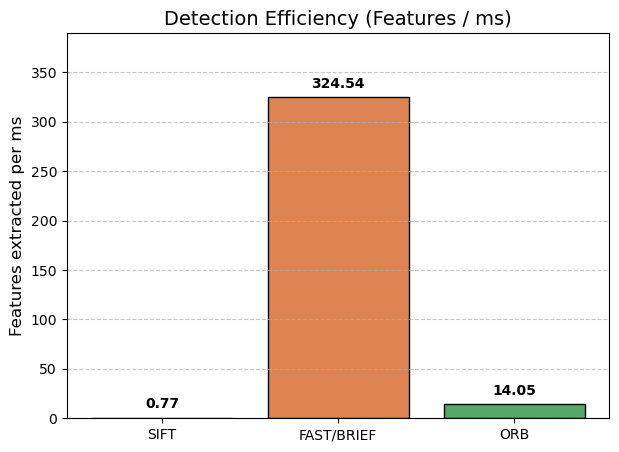

In [21]:
import time

database_images = dataset.get_database_images()

# Parameters match Task 9 so the comparison is fair
speed_configs = {
    'SIFT':       dict(feat_type='SIFT',       nfeats=1000, thresh=25),
    'FAST/BRIEF': dict(feat_type='FAST_BRIEF', nfeats=1000, thresh=25),
    'ORB':        dict(feat_type='ORB',        nfeats=1000, thresh=25),
}

results_speed = {}

print(f"{'Method':<12} | {'Avg Time (ms)':<15} | {'Avg Feats':<10} | {'Feats/ms':<10}")
print("-" * 55)

for method, cfg in speed_configs.items():
    times_ms = []
    feat_counts = []

    for img_name in database_images:
        img = dataset.get_image(img_name)
        if img is None: continue
        
        t0 = time.perf_counter()                           # High-resolution timer start
        kp, des = a1.extract_interest_points(img, **cfg)   # Detection + description
        t1 = time.perf_counter()                           # Timer end
        
        times_ms.append((t1 - t0) * 1000)                  # Convert seconds → ms
        feat_counts.append(len(kp) if kp is not None else 0)

    avg_ms = np.mean(times_ms)
    avg_feats = np.mean(feat_counts)
    feats_per_ms = avg_feats / avg_ms if avg_ms > 0 else 0
    
    results_speed[method] = feats_per_ms
    print(f"{method:<12} | {avg_ms:<15.2f} | {avg_feats:<10.1f} | {feats_per_ms:<10.2f}")

# ── Plot 1 Visualization: Detection Efficiency ──────────────────────────────
plt.figure(figsize=(7, 5))
methods_s = list(results_speed.keys())
feats_per_ms_vals = list(results_speed.values())

bars = plt.bar(methods_s, feats_per_ms_vals, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(feats_per_ms_vals)*0.02), 
             f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('Detection Efficiency (Features / ms)', fontsize=14)
plt.ylabel('Features extracted per ms', fontsize=12)
plt.ylim(0, max(feats_per_ms_vals) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Deep Descriptors**

In this section, we will use neural networks pre-trained on millions of images (ImageNet) to let them tell us what is important in an image.

The result of passing an image through these networks is an **embedding**: a high-dimensional numerical vector that represents the **semantic meaning** of the image.

## Architectures

- Complete the `CNNFeatureExtractor` class in the `assignment1.py` file. The ResNet-50 architecture is loaded using PyTorch (torchvision). Next, we remove the final classification layer, and set up the required preprocessing to use it as a feature extractor. We will extract the vector from the penultimate layer (Average Pooling), which has **2048 dimensions**. You just need to complete the `extract_feature` method.

- Similarly, complete the `ViTFeatureExtractor` class in the `assignment1.py` file. A Vision Transformer (ViT) model is loaded. Next, the classification head to extract the class token ([CLS]) is replaced by the identity to obtain the final image embedding, which has **768 dimensions**. You just need to complete the `extract_feature` method.

Remember in both cases that the resulting vector must be L2-normalized in order to compare them using the Cosine distance.

Check your implementations using the following cell:

In [17]:
dataset = HolidaysDatasetHandler(dataset_dir, load_features=False)

img = dataset.get_image('100000.jpg')

cnn = a1.CNNFeatureExtractor()
f_cnn = cnn.extract_feature(img)
print(f"ResNet Shape: {f_cnn.shape}")

vit = a1.ViTFeatureExtractor()
f_vit = vit.extract_feature(img)
print(f"ViT Shape:    {f_vit.shape}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/vacl/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100.0%


ResNet Shape: (2048,)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /home/vacl/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100.0%


ViT Shape:    (768,)


**Task 12:**

Your task in the following cell is to compute the **Mean Average Precision (mAP)** of this image retrieval system on this dataset using the `HolidaysDatasetHandler` and the classes implemented above. You should use **cosine similarity** as the metric. Note that if the extracted vectors are normalized, this is equivalent to the dot product.

In [18]:
# ── Task 12: Compute mAP for Deep Extractors ───────────────────────────────

def evaluate_deep(extractor_model):
    """
    Builds a ranked retrieval list for every query using cosine similarity
    (dot product on L2-normalized vectors) and returns mAP.
    """
    query_imgs = dataset.get_query_images()
    db_imgs = dataset.get_database_images()

    # Pre-extract features for all database images once
    db_features = {}
    for db_name in db_imgs:
        img = dataset.get_image(db_name)
        db_features[db_name] = extractor_model.extract_feature(img)

    mAP_dict = {}
    for q_name in query_imgs:
        q_img = dataset.get_image(q_name)
        q_feat = extractor_model.extract_feature(q_img)
        
        scores = []
        for db_name, db_feat in db_features.items():
            # Since vectors are L2-normalized, np.dot computes the cosine similarity
            similarity = np.dot(q_feat, db_feat)
            scores.append((db_name, similarity))
            
        # Sort descending: highest similarity first
        scores.sort(key=lambda x: x[1], reverse=True)
        mAP_dict[q_name] = [name for name, _ in scores]
        
    return dataset.compute_mAP(mAP_dict)

# Instantiate extractors and evaluate
print("Evaluating CNN (ResNet-50)...")
cnn = a1.CNNFeatureExtractor()
mAP_cnn = evaluate_deep(cnn)
print(f"  Done. mAP CNN = {mAP_cnn:.5f}")

print("Evaluating ViT (ViT-B/16)...")
vit = a1.ViTFeatureExtractor()
mAP_vit = evaluate_deep(vit)
print(f"  Done. mAP ViT = {mAP_vit:.5f}")

Evaluating CNN (ResNet-50)...
  Done. mAP CNN = 1.00000
Evaluating ViT (ViT-B/16)...
  Done. mAP ViT = 0.96053


**Task 13:**

Compare the methods in terms of accuracy. Additionally, compare these approaches with those developed previously in this assignment.

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

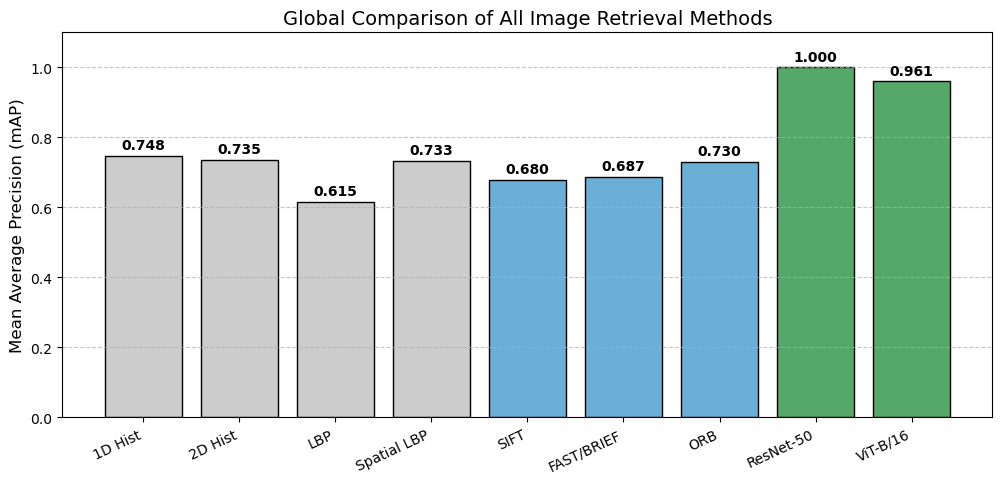


Overall Ranking by accuracy (mAP):
  1. ResNet-50      : 1.00000
  2. ViT-B/16       : 0.96053
  3. 1D Hist        : 0.74751
  4. 2D Hist        : 0.73546
  5. Spatial LBP    : 0.73307
  6. ORB            : 0.73009
  7. FAST/BRIEF     : 0.68706
  8. SIFT           : 0.67990
  9. LBP            : 0.61529

--- Final Analysis ---
Deep descriptors (ResNet-50) significantly outperform earlier handcrafted classical methods.


In [22]:
# Collect all results using the precise variable names from earlier tasks
all_methods = [
    '1D Hist', '2D Hist', 'LBP', 'Spatial LBP', 
    'SIFT', 'FAST/BRIEF', 'ORB', 
    'ResNet-50', 'ViT-B/16'
]

all_mAPs = [
    mAP_hist_1d,      # from Task 1
    mAP_hist_2d,      # from Task 3
    mAP_lbp,          # from Task 6
    mAP_global_lbp,   # from Task 8
    best_mAP_SIFT,    # from Task 9
    best_mAP_FASTBRIEF, 
    best_mAP_ORB,     
    mAP_cnn,          # from Task 12
    mAP_vit           
]

# Color code: Grays for Global, Blues for Local, Greens for Deep Learning
colors = ['#cccccc']*4 + ['#6baed6']*3 + ['#55A868']*2

plt.figure(figsize=(12, 5))
bars = plt.bar(all_methods, all_mAPs, color=colors, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
             f'{yval:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Global Comparison of All Image Retrieval Methods', fontsize=14)
plt.ylabel('Mean Average Precision (mAP)', fontsize=12)
plt.ylim(0, 1.1)  # mAP goes from 0 to 1, leaving room for labels
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print ranked summary
ranked_all = sorted(zip(all_methods, all_mAPs), key=lambda x: x[1], reverse=True)
print("\nOverall Ranking by accuracy (mAP):")
for rank, (method, score) in enumerate(ranked_all, 1):
    print(f"  {rank}. {method:<15}: {score:.5f}")

print("\n--- Final Analysis ---")
print(f"Deep descriptors ({ranked_all[0][0]}) significantly outperform earlier handcrafted classical methods.")

## Submitting Your Work

**Important**: Please ensure that the notebook has been run and that the **cell outputs are visible**.

**Important**: Additionally, make sure you have filled in the names at the beginning of the notebook and the **ID** variable in the following cell.

Once you have completed the necessary code and are satisfied with your solution, **save your notebook** and run the following cell:

In [19]:
ID = '99999999R' # Your DNI or NIE

zip_filename = ID + '_A1.zip'
zf = zipfile.ZipFile(zip_filename, mode = 'w')

zf.write('11762_Image_Description.ipynb');
zf.write('assignment1.py');
zf.write('holidays_dataset_handler.py');

zf.close()

This will generate a zip file of your code called `ID_A1.zip` in the same directory of the assignment. This is the file that you must upload to [Aula Digital](https://ad.uib.es/) to submit your work!

---

&copy; Emilio Garcia-Fidalgo, University of the Balearic Islands